# Multi-temporal land-cover change detection
### using EuroSAT transfer learning, validated against Global Forest Watch
---

**Abstract.** This notebook develops an end-to-end system that (1) trains a land-cover
classifier on the EuroSAT dataset using transfer learning with a ResNet-50 backbone,
(2) applies the classifier to multi-temporal Sentinel-2 imagery of a single region captured
in two different years, (3) detects land-cover transitions indicative of deforestation
(Forest → Farmland/Pasture/Built-up), and (4) validates the detected changes against the
Hansen Global Forest Change dataset (the data backing Global Forest Watch).

**Research question.** *Can a transfer-learning land-cover classifier accurately detect
deforestation by comparing satellite images from different years, and how well do these
detections agree with official environmental reports?*

**Why EuroSAT + Sentinel-2.** EuroSAT is itself derived from Sentinel-2 imagery. By sourcing
the study-region scenes from Sentinel-2 as well, the classifier operates in-domain at
inference time, which is essential for reliable change detection.

---

### Contents
1. [Environment & configuration](#1)
2. [Part I — Land-cover classifier](#2)
&nbsp;&nbsp; 2.1 Data exploration · 2.2 Preprocessing · 2.3 Model · 2.4 Training · 2.5 Evaluation
3. [Part II — Multi-temporal change detection](#3)
&nbsp;&nbsp; 3.1 Imagery acquisition · 3.2 Tiled inference · 3.3 Land-cover maps · 3.4 Change detection
4. [Part III — Validation against Global Forest Watch](#4)
5. [Conclusion, limitations & next steps](#5)

<a id="1"></a>
## 1. Environment & configuration

In [9]:
# Install dependencies if needed (Colab / Kaggle):
# !pip install torch torchvision scikit-learn matplotlib seaborn rasterio earthengine-api geemap

import os
import json
import warnings

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

torch.manual_seed(69); np.random.seed(69)
print("PyTorch", torch.__version__, "| device:", DEVICE)

PyTorch 2.12.1 | device: mps


All tunable parameters live in one place. Paths assume the notebook runs from
`notebooks/` inside the repo; adjust for Colab/Kaggle as needed.

In [97]:
# ----- paths -----
DATA_DIR     = "../data/EuroSAT"             # EuroSAT RGB: data/2750/<Class>/*.jpg
SCENE_DIR    = "../data/study_region"     # Sentinel-2 GeoTIFFs (two years) + Hansen loss
WEIGHTS_DIR  = "../outputs/weights"
PRED_DIR     = "../outputs/predictions"
ASSETS_DIR   = "../assets"
for d in (WEIGHTS_DIR, PRED_DIR, ASSETS_DIR):
    os.makedirs(d, exist_ok=True)

# ----- model / training -----
TILE         = 3                         # EuroSAT image size & inference window
BATCH_SIZE   = 64
SEED         = 69
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
CKPT         = os.path.join(WEIGHTS_DIR, "resnet50_eurosat.pt")

# ----- study region / temporal window -----
YEAR_1, YEAR_2 = 2018, 2024
BBOX = [-123.4, 46.8, -122.9, 47.2]       # [W, S, E, N] — WA Cascades clear-cut forestry           
SCENE_RES_M  = 10                         # Sentinel-2 native metres/pixel
TILE_METERS  = TILE * SCENE_RES_M         # ground size of one classified tile (640 m)

# classes that, when forest converts to them, indicate likely deforestation
DEFOREST_TO = {"AnnualCrop","Pasture","PermanentCrop","HerbaceousVegetation",
               "Residential","Industrial","Highway"}

<a id="2"></a>
## 2. Part I — Land-cover classifier

We train a 10-class land-cover classifier on EuroSAT. Download the RGB archive
(`EuroSAT.zip`) from [Zenodo](https://zenodo.org/records/7711810) and unzip so the
`2750/` folder sits under `data/`.

### 2.1 Data exploration

10 classes, 27000 images total


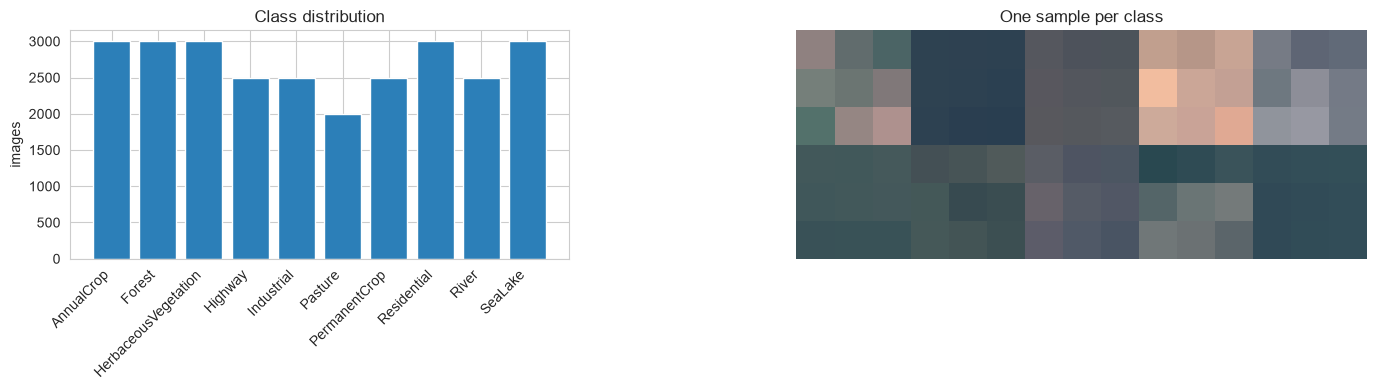

In [110]:
LABELS = [d for d in os.listdir(DATA_DIR) if not d.startswith(".")]
LABELS = sorted(d for d in LABELS if os.path.isdir(os.path.join(DATA_DIR, d)))
counts = {l: len(os.listdir(os.path.join(DATA_DIR, l))) for l in LABELS}
print(f"{len(LABELS)} classes, {sum(counts.values())} images total")


fig, ax = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"width_ratios":[1, 2]})
ax[0].bar(counts.keys(), counts.values(), color="#2c7fb8")
ax[0].set_xticklabels(counts.keys(), rotation=45, ha="right")
ax[0].set_ylabel("images"); ax[0].set_title("Class distribution")

# sample tile per class
grid = np.zeros((2*TILE, 5*TILE, 3), dtype=np.uint8)
for i, l in enumerate(LABELS):
    s = os.listdir(os.path.join(DATA_DIR, l))[0]
    img = np.array(Image.open(os.path.join(DATA_DIR, l, s)).resize((TILE, TILE)))
    r, col = divmod(i, 5)
    grid[r*TILE:(r+1)*TILE, col*TILE:(col+1)*TILE] = img
ax[1].imshow(grid); ax[1].axis("off"); ax[1].set_title("One sample per class")
plt.tight_layout(); plt.show()

### 2.2 Preprocessing & augmentation

Augmentation (flips, rotation, shift, shear, zoom) follows the standard EuroSAT recipe.
ImageNet normalization is applied because the backbone is ImageNet-pretrained. The
train/test split is **stratified** by class so every class is proportionally represented.

In [5]:
train_tf = transforms.Compose([
    transforms.Resize((TILE, TILE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(60),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), shear=20, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((TILE, TILE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

base_train = datasets.ImageFolder(DATA_DIR, transform=train_tf)
base_eval  = datasets.ImageFolder(DATA_DIR, transform=eval_tf)
CLASSES      = base_train.classes
CLASS_TO_IDX = base_train.class_to_idx
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

targets = np.array(base_train.targets)
tr_idx, te_idx = train_test_split(np.arange(len(targets)), test_size=0.2,
                                  random_state=SEED, stratify=targets)
train_ds, test_ds = Subset(base_train, tr_idx), Subset(base_eval, te_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

with open(os.path.join(WEIGHTS_DIR, "class_to_idx.json"), "w") as f:
    json.dump(CLASS_TO_IDX, f, indent=2)
print(f"train {len(train_ds)} | test {len(test_ds)} | classes {CLASSES}")

train 21600 | test 5400 | classes ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


### 2.3 Model — ResNet-50 transfer learning

The ImageNet-pretrained ResNet-50 convolutional backbone is reused as a feature extractor;
its final fully-connected layer is replaced by a small two-layer classifier head. A helper
toggles which parameters are trainable, supporting the two-stage training schedule.

In [13]:
def build_model(n_classes, freeze_backbone=True):
    """ResNet-50 with a custom 2-layer head replacing `fc`."""
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    in_features = model.fc.in_features                 # 2048
    model.fc = nn.Sequential(
        nn.Linear(in_features, 2048), nn.ReLU(inplace=True), nn.Dropout(0.2),
        nn.Linear(2048, n_classes),
    )
    set_backbone_trainable(model, trainable=not freeze_backbone)
    return model

def set_backbone_trainable(model, trainable):
    """Keep the head trainable; freeze/unfreeze everything else."""
    for name, p in model.named_parameters():
        p.requires_grad = True if name.startswith("fc.") else trainable

model = build_model(len(CLASSES), freeze_backbone=True).to(DEVICE)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable params (stage 1): {n_trainable:,}")

trainable params (stage 1): 4,216,842


### 2.4 Training

A two-stage transfer-learning schedule:

| Stage | Backbone | LR | Purpose |
|-------|----------|----|---------|
| 1 | frozen | 1e-3 | learn the new head on EuroSAT features |
| 2 | unfrozen | 1e-4 | fine-tune the whole network end-to-end |

Stage 2 uses `ReduceLROnPlateau` and early stopping on validation accuracy, checkpointing the
best weights.

In [7]:
def run_epoch(model, loader, criterion, optimizer, train):
    model.train() if train else model.eval()
    loss_sum = correct = total = 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if train: optimizer.zero_grad()
            out = model(x); loss = criterion(out, y)
            if train: loss.backward(); optimizer.step()
            loss_sum += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            total    += x.size(0)
    return loss_sum / total, correct / total

def fit(model, epochs, lr, patience, ckpt, use_scheduler=False):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    scheduler = (torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-5) if use_scheduler else None)
    best_acc = wait = 0
    history = []
    for epoch in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, criterion, optimizer, True)
        va = run_epoch(model, val_loader,  criterion, optimizer, False)
        if scheduler: scheduler.step(va[1])
        history.append((tr[1], va[1]))
        print(f"epoch {epoch:3d} | train {tr[1]:.4f} | val {va[1]:.4f} (loss {va[0]:.4f})")
        if va[1] > best_acc:
            best_acc, wait = va[1], 0; torch.save(model.state_dict(), ckpt)
        else:
            wait += 1
            if wait >= patience:
                print(f"early stopping @ epoch {epoch}"); break
    print(f"best val accuracy: {best_acc:.4f}")
    return history

In [22]:
# Stage 1 — train head (backbone frozen).
# For a quick smoke test set epochs=3 first, then raise to 50.
hist1 = fit(model, epochs=50, lr=1e-3, patience=10, ckpt=CKPT)

epoch   1 | train 0.6974 | val 0.6717 (loss 1.0247)
epoch   2 | train 0.7514 | val 0.7343 (loss 0.8473)
epoch   3 | train 0.7625 | val 0.7156 (loss 1.0251)
epoch   4 | train 0.7704 | val 0.7665 (loss 0.7474)
epoch   5 | train 0.7766 | val 0.7237 (loss 0.8809)
epoch   6 | train 0.7730 | val 0.7361 (loss 0.8676)
epoch   7 | train 0.7777 | val 0.7478 (loss 0.7975)
epoch   8 | train 0.7817 | val 0.7561 (loss 0.7565)
epoch   9 | train 0.7852 | val 0.7624 (loss 0.7555)
epoch  10 | train 0.7842 | val 0.7556 (loss 0.7686)
epoch  11 | train 0.7927 | val 0.7498 (loss 0.7738)
epoch  12 | train 0.7859 | val 0.7713 (loss 0.7348)
epoch  13 | train 0.7908 | val 0.7839 (loss 0.7052)
epoch  14 | train 0.7935 | val 0.7576 (loss 0.7953)
epoch  15 | train 0.7905 | val 0.7606 (loss 0.7792)
epoch  16 | train 0.7972 | val 0.7685 (loss 0.7428)
epoch  17 | train 0.7944 | val 0.7728 (loss 0.7307)
epoch  18 | train 0.7982 | val 0.7887 (loss 0.6857)
epoch  19 | train 0.7936 | val 0.7648 (loss 0.7738)
epoch  20 | 

epoch   1 | train 0.8888 | val 0.9246 (loss 0.2456)
epoch   2 | train 0.9280 | val 0.9448 (loss 0.1740)
epoch   3 | train 0.9434 | val 0.9572 (loss 0.1420)
epoch   4 | train 0.9505 | val 0.9572 (loss 0.1375)
epoch   5 | train 0.9557 | val 0.9591 (loss 0.1206)
epoch   6 | train 0.9606 | val 0.9646 (loss 0.1049)
epoch   7 | train 0.9644 | val 0.9706 (loss 0.0928)
epoch   8 | train 0.9660 | val 0.9687 (loss 0.0938)
epoch   9 | train 0.9681 | val 0.9737 (loss 0.0782)
epoch  10 | train 0.9683 | val 0.9763 (loss 0.0766)
epoch  11 | train 0.9720 | val 0.9763 (loss 0.0740)
epoch  12 | train 0.9736 | val 0.9763 (loss 0.0793)
epoch  13 | train 0.9731 | val 0.9735 (loss 0.0827)
epoch  14 | train 0.9730 | val 0.9765 (loss 0.0766)
epoch  15 | train 0.9784 | val 0.9743 (loss 0.0856)
epoch  16 | train 0.9767 | val 0.9765 (loss 0.0704)
epoch  17 | train 0.9789 | val 0.9670 (loss 0.1114)
epoch  18 | train 0.9772 | val 0.9754 (loss 0.0868)
epoch  19 | train 0.9818 | val 0.9789 (loss 0.0749)
epoch  20 | 

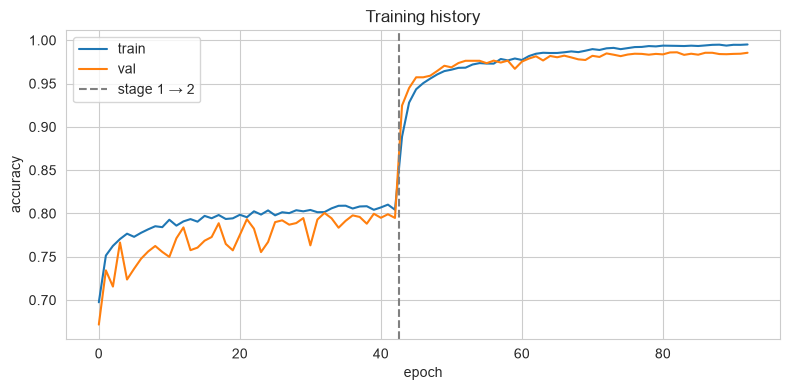

In [23]:
# Stage 2 — fine-tune end-to-end (backbone unfrozen).
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
set_backbone_trainable(model, trainable=True)
hist2 = fit(model, epochs=100, lr=1e-4, patience=10, ckpt=CKPT, use_scheduler=True)

# learning curves
acc = [h[0] for h in hist1+hist2]; val = [h[1] for h in hist1+hist2]
plt.figure(figsize=(8,4))
plt.plot(acc, label="train"); plt.plot(val, label="val")
plt.axvline(len(hist1)-0.5, ls="--", c="grey", label="stage 1 → 2")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.title("Training history")
plt.tight_layout(); plt.show()

### 2.5 Evaluation

Accuracy, per-class precision/recall/F1, and the confusion matrix on the held-out test set.
Both artifacts are saved to `results/` for the write-up.

                      precision    recall  f1-score   support

          AnnualCrop     0.9801    0.9833    0.9817       600
              Forest     0.9967    0.9967    0.9967       600
HerbaceousVegetation     0.9784    0.9833    0.9809       600
             Highway     0.9763    0.9880    0.9821       500
          Industrial     0.9939    0.9840    0.9889       500
             Pasture     0.9922    0.9575    0.9746       400
       PermanentCrop     0.9741    0.9760    0.9750       500
         Residential     0.9884    0.9983    0.9934       600
               River     0.9802    0.9880    0.9841       500
             SeaLake     1.0000    0.9950    0.9975       600

            accuracy                         0.9861      5400
           macro avg     0.9860    0.9850    0.9855      5400
        weighted avg     0.9862    0.9861    0.9861      5400



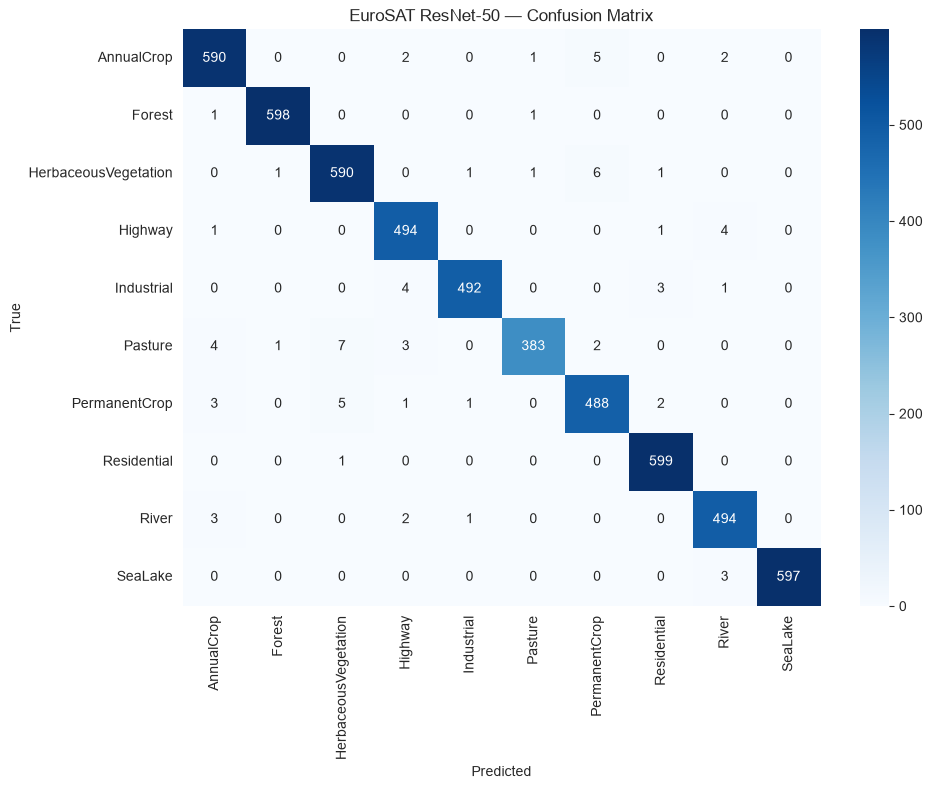

In [24]:
model.load_state_dict(torch.load(CKPT, map_location=DEVICE)); model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in val_loader:
        y_pred.extend(model(x.to(DEVICE)).argmax(1).cpu().numpy()); y_true.extend(y.numpy())

report = classification_report(y_true, y_pred, target_names=CLASSES, digits=4)
print(report)
open(os.path.join(ASSETS_DIR, "classification_report.txt"), "w").write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.ylabel("True"); plt.xlabel("Predicted"); plt.title("EuroSAT ResNet-50 — Confusion Matrix")
plt.tight_layout(); plt.savefig(os.path.join(ASSETS_DIR, "confusion_matrix.png"), dpi=150); plt.show()

<a id="3"></a>
## 3. Part II — Multi-temporal change detection

With a trained classifier we now move to the deforestation task: acquire Sentinel-2 RGB
imagery for the **same region in two years**, classify every 64×64 tile of each scene, and
compare the resulting land-cover maps.

### 3.1 Imagery acquisition (Google Earth Engine)

Requires a free Earth Engine account (`earthengine authenticate` once). This exports two
cloud-masked annual median composites plus the Hansen forest-loss layer to Google Drive;
download them into `data/study_region/`. Skip this cell if you already have the GeoTIFFs.

In [35]:
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.0
    Uninstalling pip-25.0:
      Successfully uninstalled pip-25.0


In [38]:
import sys
!{sys.executable} -m pip uninstall -y ee
!{sys.executable} -m pip install earthengine-api geemap

Found existing installation: ee 0.2
Uninstalling ee-0.2:
  Successfully uninstalled ee-0.2
  Using cached uritemplate-4.2.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached google_crc32c-1.8.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (1.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 15.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 16.9 MB/s  0:00:00 17.7 MB/s eta 0:00:01
Using cached uritemplate-4.2.0-py3-none-any.whl (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 15.3 MB/s  0:00:00 16.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.5 MB/s  0:00:00
Using cached pyasn1_modules-0.4.2-py3-none-any.whl (181 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.8/574.8 kB 13.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.4/935.4 kB 13.9 MB/s  0:00:00
Using cached google_crc32c-1.8.0-cp313-cp313-macosx_12_0_arm64.whl (3

In [40]:
import ee, os
cred = os.path.expanduser("~/.config/earthengine/credentials")
if os.path.exists(cred):
    os.remove(cred)
    print("old credentials deleted")
ee.Authenticate()
ee.Initialize(project="ml-deforestation")
print(ee.Number(1).add(1).getInfo())   # should print 2

old credentials deleted



Successfully saved authorization token.
2


Agreement with Global Forest Watch (Hansen):
  True positives : 0
  False positives: 1114
  False negatives: 0
  Precision      : 0.000
  Recall         : 0.000
  F1             : 0.000
  IoU            : 0.000


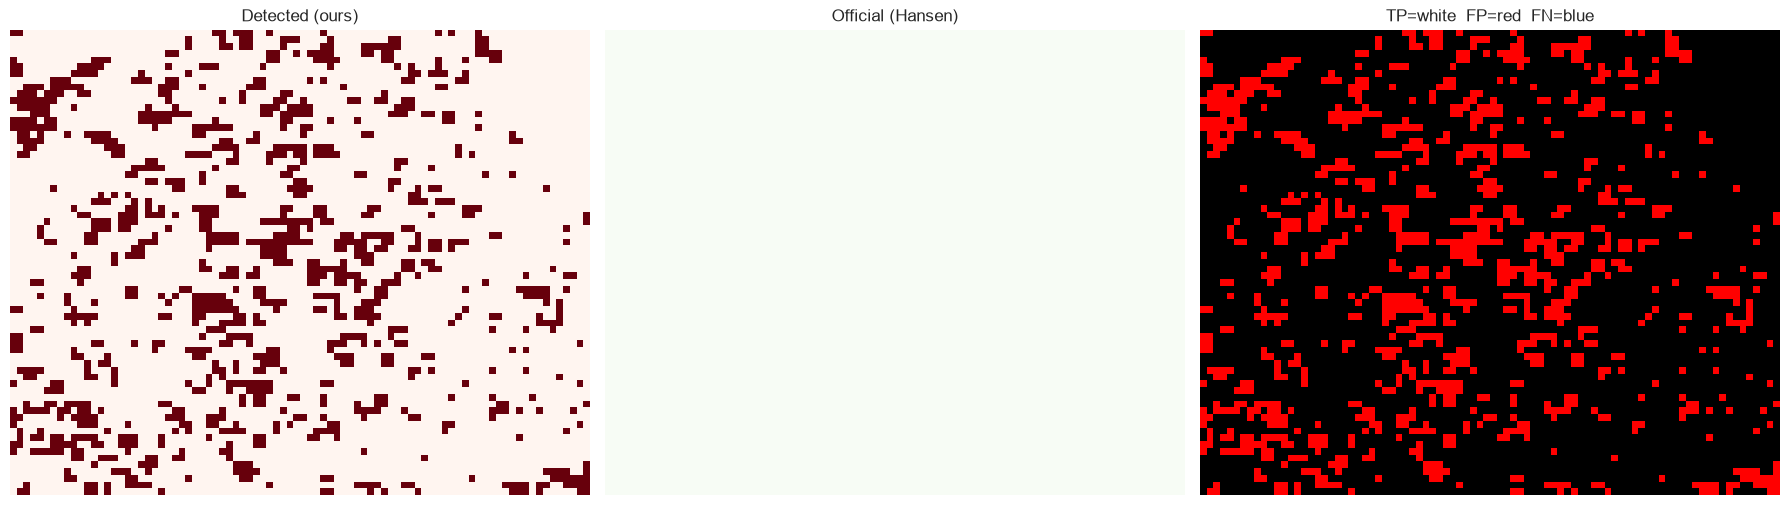

In [98]:
def hansen_loss_grid(hansen_path, year1, year2, frac_threshold=0.05):
    """Aggregate the Hansen lossyear raster to the tile grid.
    lossyear value = (year of loss − 2000); 0 means no loss."""
    lo, hi = year1 - 2000, year2 - 2000
    with rasterio.open(hansen_path) as src:
        arr = src.read(1).astype(np.int16)
    loss_px = (arr >= lo) & (arr <= hi)
    H, W = loss_px.shape
    rows, cols = H // TILE, W // TILE
    frac = loss_px[:rows*TILE, :cols*TILE].reshape(rows, TILE, cols, TILE).mean(axis=(1,3))
    return frac >= frac_threshold

hansen_path = os.path.join(SCENE_DIR, "hansen_lossyear.tif")
if "change_mask" in globals() and os.path.exists(hansen_path):
    official = hansen_loss_grid(hansen_path, YEAR_1, YEAR_2)
    # align shapes (rasters may differ by a row/col)
    R = min(change_mask.shape[0], official.shape[0]); C = min(change_mask.shape[1], official.shape[1])
    det, off = change_mask[:R,:C], official[:R,:C]

    TP = int((det & off).sum()); FP = int((det & ~off).sum())
    FN = int((~det & off).sum()); TN = int((~det & ~off).sum())
    precision = TP / (TP + FP + 1e-9)
    recall    = TP / (TP + FN + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    iou       = TP / (TP + FP + FN + 1e-9)

    print("Agreement with Global Forest Watch (Hansen):")
    print(f"  True positives : {TP}")
    print(f"  False positives: {FP}")
    print(f"  False negatives: {FN}")
    print(f"  Precision      : {precision:.3f}")
    print(f"  Recall         : {recall:.3f}")
    print(f"  F1             : {f1:.3f}")
    print(f"  IoU            : {iou:.3f}")

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    ax[0].imshow(det,  cmap="Reds");   ax[0].set_title("Detected (ours)");     ax[0].axis("off")
    ax[1].imshow(off,  cmap="Greens"); ax[1].set_title("Official (Hansen)");   ax[1].axis("off")
    agreement = np.zeros((*det.shape, 3))
    agreement[det & off]   = [1,1,1]      # TP white
    agreement[det & ~off]  = [1,0,0]      # FP red
    agreement[~det & off]  = [0,0,1]      # FN blue
    ax[2].imshow(agreement); ax[2].set_title("TP=white  FP=red  FN=blue"); ax[2].axis("off")
    plt.tight_layout(); plt.savefig(os.path.join(ASSETS_DIR, "validation.png"), dpi=150); plt.show()

    json.dump({"TP":TP,"FP":FP,"FN":FN,"TN":TN,"precision":precision,"recall":recall,
               "f1":f1,"iou":iou}, open(os.path.join(ASSETS_DIR,"validation.json"),"w"), indent=2)
else:
    print("Need change_mask (3.4) and data/study_region/hansen_lossyear.tif first.")

In [96]:
def export_imagery(bbox, year1, year2, scale=10, folder="deforestation"):
    import ee
    region = ee.Geometry.Rectangle(bbox)

    def s2_rgb(year):
        start, end = f"{year}-06-01", f"{year}-09-15"   # season-matched summer window, both years
        col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
            .filterBounds(region).filterDate(start, end)
            .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
            .select(["B4", "B3", "B2"]))          # <- select bands on the collection first
        return col.median().clip(region)             # <- then reduce
    
    def s2_ndvi(year):
        start, end = f"{year}-06-01", f"{year}-09-15"
        col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
               .filterBounds(region).filterDate(start, end)
                .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
               .select(["B8", "B4"]))                       # NIR, Red
        ndvi = col.median().normalizedDifference(["B8", "B4"]).rename("NDVI")
        return ndvi.clip(region)                            # values in [-1, 1]

    for year in (year1, year2):
        ee.batch.Export.image.toDrive(image=s2_ndvi(year), description=f"ndvi_{year}",
            folder=folder, region=region, scale=scale, maxPixels=int(1e13)).start()
        print("export started:", f"ndvi_{year}")

    for year in (year1, year2):
        img = s2_rgb(year).visualize(min=0, max=3000)               # -> 8-bit 0..255
        ee.batch.Export.image.toDrive(image=img, description=f"s2_rgb_{year}",
            folder=folder, region=region, scale=scale, maxPixels=int(1e13)).start()
        print("export started:", f"s2_rgb_{year}")

    hansen = (ee.Image("UMD/hansen/global_forest_change_2023_v1_11")
              .select("lossyear").clip(region))
    ee.batch.Export.image.toDrive(image=hansen, description="hansen_lossyear",
        folder=folder, region=region, scale=scale, maxPixels=int(1e13)).start()
    print("export started: hansen_lossyear")

export_imagery(BBOX, YEAR_1, YEAR_2, scale=SCENE_RES_M)

export started: ndvi_2018
export started: ndvi_2024
export started: s2_rgb_2018
export started: s2_rgb_2024
export started: hansen_lossyear


In [47]:
import json

# rebuild the architecture and load the trained weights from disk
with open(os.path.join(WEIGHTS_DIR, "class_to_idx.json")) as f:
    CLASS_TO_IDX = json.load(f)
CLASSES = list(CLASS_TO_IDX.keys())
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

model = build_model(len(CLASSES), freeze_backbone=False).to(DEVICE)
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
model.eval()
print("model loaded:", len(CLASSES), "classes")

model loaded: 10 classes


### 3.2 Tiled inference

We slide a non-overlapping 64×64 window across each scene, normalize each tile exactly as in
training, and record the predicted class — yielding a low-resolution land-cover label grid
for each year (one cell per 640 m × 640 m tile).

In [23]:
import rasterio
_MEAN = np.array(IMAGENET_MEAN).reshape(3,1,1)
_STD  = np.array(IMAGENET_STD).reshape(3,1,1)

@torch.no_grad()
def classify_scene(tif_path, model, batch=256):
    """Return a (rows, cols) grid of predicted class indices for one scene."""
    with rasterio.open(tif_path) as src:
        img = src.read([1,2,3]).astype(np.float32)        # (3,H,W), 0..255 expected
    _, H, W = img.shape
    rows, cols = H // TILE, W // TILE
    grid = np.full((rows, cols), -1, dtype=np.int64)
    buf, coords = [], []
    def flush():
        if not buf: return
        t = torch.from_numpy(np.stack(buf)).float().to(DEVICE)
        preds = model(t).argmax(1).cpu().numpy()
        for (r,col_), p in zip(coords, preds): grid[r, col_] = p
        buf.clear(); coords.clear()
    for r in range(rows):
        for col_ in range(cols):
            patch = img[:, r*TILE:(r+1)*TILE, col_*TILE:(col_+1)*TILE] / 255.0
            patch = (patch - _MEAN) / _STD
            buf.append(patch.astype(np.float32)); coords.append((r, col_))
            if len(buf) >= batch: flush()
    flush()
    return grid

scene1 = os.path.join(SCENE_DIR, f"s2_rgb_{YEAR_1}.tif")
scene2 = os.path.join(SCENE_DIR, f"s2_rgb_{YEAR_2}.tif")
if os.path.exists(scene1) and os.path.exists(scene2):
    grid1 = classify_scene(scene1, model)
    grid2 = classify_scene(scene2, model)
    np.save(os.path.join(PRED_DIR, f"grid_{YEAR_1}.npy"), grid1)
    np.save(os.path.join(PRED_DIR, f"grid_{YEAR_2}.npy"), grid2)
    print("grids:", grid1.shape, grid2.shape)
else:
    print("Study-region scenes not found — run 3.1 and download the GeoTIFFs first.")

grids: (69, 104) (69, 104)


### 3.3 Land-cover maps

Render each year's classified grid with a consistent colour per class so changes are visible
by eye before quantification.

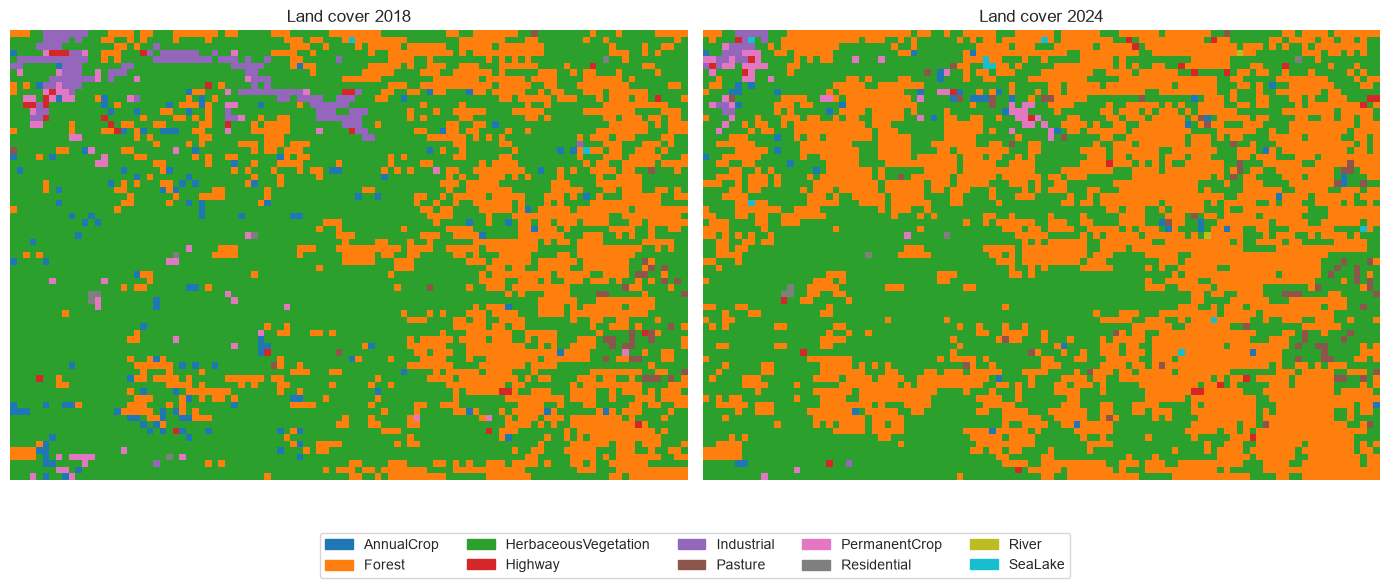

In [36]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

def plot_landcover(grids, titles):
    palette = plt.cm.tab10(np.linspace(0, 1, len(CLASSES)))
    cmap = ListedColormap(palette)
    fig, axes = plt.subplots(1, len(grids), figsize=(7*len(grids), 6))
    axes = np.atleast_1d(axes)
    for ax, g, t in zip(axes, grids, titles):
        ax.imshow(g, cmap=cmap, vmin=0, vmax=len(CLASSES)-1); ax.set_title(t); ax.axis("off")
    handles = [Patch(color=palette[i], label=CLASSES[i]) for i in range(len(CLASSES))]
    fig.legend(handles=handles, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout(); plt.show()

if "grid1" in globals():
    plot_landcover([grid1, grid2], [f"Land cover {YEAR_1}", f"Land cover {YEAR_2}"])

### 3.4 Change detection

A tile is flagged as **deforestation** when it was `Forest` in year 1 and converts to a
non-forest, human-associated class in year 2. We report the affected area and a transition
breakdown, and save a change mask.

Forest LOSS: 178224 tiles  (~160.40 km²)
Forest GAIN: 162894 tiles  (~146.60 km²)
NET change : -15330 tiles  (~-13.80 km²)  (net loss)


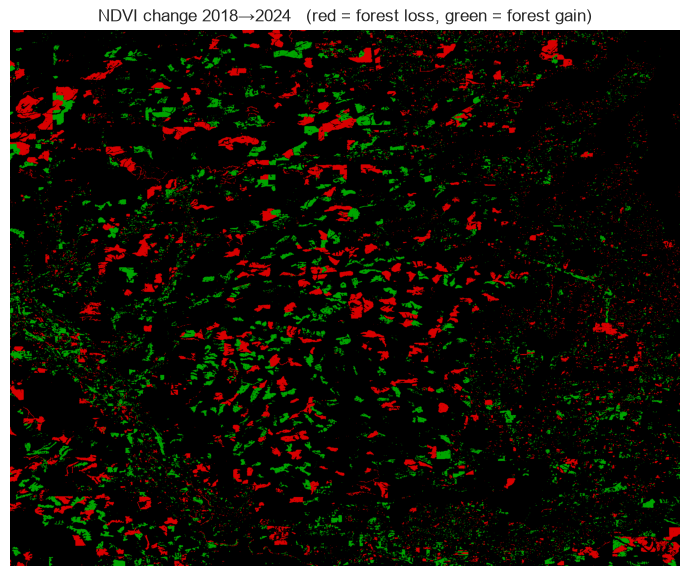

In [103]:
import rasterio

def _read1(path):
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32)

# --- tunable thresholds ---
FOREST_NDVI = 0.60     # tile counts as vegetated/forest in year 1 if NDVI >= this
DROP        = 0.18     # greenness must fall by at least this much to be "loss"
GAIN        = 0.25     # greenness must rise by at least this much to be "gain"
FRAC        = 0.11     # >= this fraction of a tile's pixels must change

def ndvi_change(ndvi1, ndvi2):
    loss_px = (ndvi1 >= FOREST_NDVI) & ((ndvi1 - ndvi2) >= DROP)
    gain_px = (ndvi2 >= FOREST_NDVI) & ((ndvi2 - ndvi1) >= GAIN)

    def to_tiles(px):
        H, W = px.shape
        rows, cols = H // TILE, W // TILE
        frac = px[:rows*TILE, :cols*TILE].reshape(rows, TILE, cols, TILE).mean(axis=(1, 3))
        return frac >= FRAC
    return to_tiles(loss_px), to_tiles(gain_px)


ndvi_path1 = os.path.join(SCENE_DIR, f"ndvi_{YEAR_1}.tif")
ndvi_path2 = os.path.join(SCENE_DIR, f"ndvi_{YEAR_2}.tif")

if os.path.exists(ndvi_path1) and os.path.exists(ndvi_path2):
    ndvi1, ndvi2 = _read1(ndvi_path1), _read1(ndvi_path2)
    loss_mask, gain_mask = ndvi_change(ndvi1, ndvi2)

    area = lambda n: n * (TILE_METERS**2) / 1e6
    n_loss, n_gain = int(loss_mask.sum()), int(gain_mask.sum())
    n_net = n_gain - n_loss
    print(f"Forest LOSS: {n_loss} tiles  (~{area(n_loss):.2f} km²)")
    print(f"Forest GAIN: {n_gain} tiles  (~{area(n_gain):.2f} km²)")
    print(f"NET change : {n_net:+d} tiles  (~{area(n_net):+.2f} km²)  "
          f"({'net gain' if n_net > 0 else 'net loss'})")

    # keep change_mask = loss for the §4 Hansen validation cell
    change_mask = loss_mask
    np.save(os.path.join(PRED_DIR, "change_mask.npy"), change_mask)
    np.save(os.path.join(PRED_DIR, "gain_mask.npy"), gain_mask)

    rgb = np.zeros((*loss_mask.shape, 3))
    rgb[loss_mask] = [0.85, 0.0, 0.0]      # loss = red
    rgb[gain_mask] = [0.0, 0.65, 0.0]      # gain = green
    plt.figure(figsize=(7, 7))
    plt.imshow(rgb); plt.axis("off")
    plt.title(f"NDVI change {YEAR_1}→{YEAR_2}   (red = forest loss, green = forest gain)")
    plt.tight_layout()
    plt.savefig(os.path.join(ASSETS_DIR, "change_bidirectional.png"), dpi=150)
    plt.show()
else:
    print("NDVI scenes not found — run the export, then download "
          "ndvi_2018.tif / ndvi_2024.tif into data/study_region/")

<a id="4"></a>
## 4. Part III — Validation against Global Forest Watch

We validate our detections against the **Hansen Global Forest Change** `lossyear` layer (the
dataset behind Global Forest Watch). Hansen is a 30 m-ish per-pixel product; we aggregate it
to our 640 m tile grid — a tile counts as *official loss* if a sufficient fraction of its
pixels record loss **within our temporal window**. We then treat the official layer as ground
truth and report precision/recall of our detections against it.

Agreement with Global Forest Watch (Hansen):
  True positives : 903
  False positives: 211
  False negatives: 453
  Precision      : 0.811
  Recall         : 0.666
  F1             : 0.731
  IoU            : 0.576


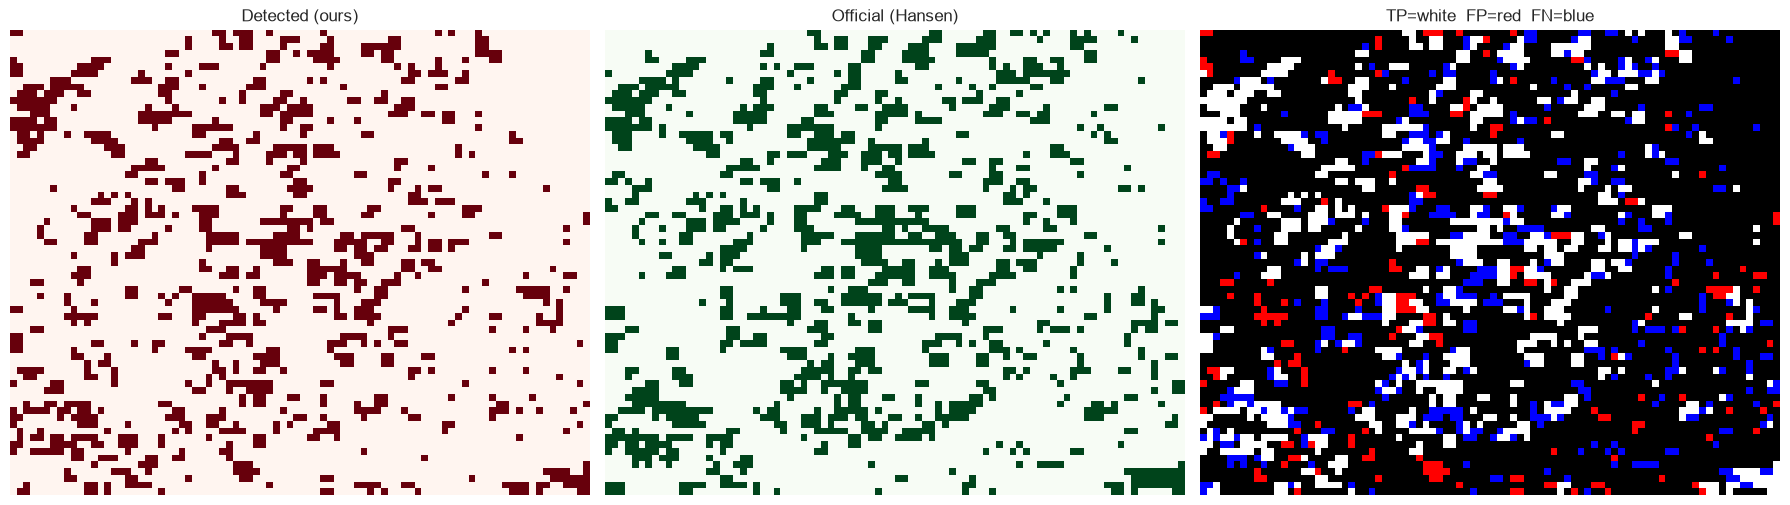

In [90]:
def hansen_loss_grid(hansen_path, year1, year2, frac_threshold=0.05):
    """Aggregate the Hansen lossyear raster to the tile grid.
    lossyear value = (year of loss − 2000); 0 means no loss."""
    lo, hi = year1 - 2000, year2 - 2000
    with rasterio.open(hansen_path) as src:
        arr = src.read(1).astype(np.int16)
    loss_px = (arr >= lo) & (arr <= hi)
    H, W = loss_px.shape
    rows, cols = H // TILE, W // TILE
    frac = loss_px[:rows*TILE, :cols*TILE].reshape(rows, TILE, cols, TILE).mean(axis=(1,3))
    return frac >= frac_threshold

hansen_path = os.path.join(SCENE_DIR, "hansen_lossyear.tif")
if "change_mask" in globals() and os.path.exists(hansen_path):
    official = hansen_loss_grid(hansen_path, YEAR_1, YEAR_2)
    # align shapes (rasters may differ by a row/col)
    R = min(change_mask.shape[0], official.shape[0]); C = min(change_mask.shape[1], official.shape[1])
    det, off = change_mask[:R,:C], official[:R,:C]

    TP = int((det & off).sum()); FP = int((det & ~off).sum())
    FN = int((~det & off).sum()); TN = int((~det & ~off).sum())
    precision = TP / (TP + FP + 1e-9)
    recall    = TP / (TP + FN + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    iou       = TP / (TP + FP + FN + 1e-9)

    print("Agreement with Global Forest Watch (Hansen):")
    print(f"  True positives : {TP}")
    print(f"  False positives: {FP}")
    print(f"  False negatives: {FN}")
    print(f"  Precision      : {precision:.3f}")
    print(f"  Recall         : {recall:.3f}")
    print(f"  F1             : {f1:.3f}")
    print(f"  IoU            : {iou:.3f}")

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    ax[0].imshow(det,  cmap="Reds");   ax[0].set_title("Detected (ours)");     ax[0].axis("off")
    ax[1].imshow(off,  cmap="Greens"); ax[1].set_title("Official (Hansen)");   ax[1].axis("off")
    agreement = np.zeros((*det.shape, 3))
    agreement[det & off]   = [1,1,1]      # TP white
    agreement[det & ~off]  = [1,0,0]      # FP red
    agreement[~det & off]  = [0,0,1]      # FN blue
    ax[2].imshow(agreement); ax[2].set_title("TP=white  FP=red  FN=blue"); ax[2].axis("off")
    plt.tight_layout(); plt.savefig(os.path.join(ASSETS_DIR, "validation.png"), dpi=150); plt.show()

    json.dump({"TP":TP,"FP":FP,"FN":FN,"TN":TN,"precision":precision,"recall":recall,
               "f1":f1,"iou":iou}, open(os.path.join(ASSETS_DIR,"validation.json"),"w"), indent=2)
else:
    print("Need change_mask (3.4) and data/study_region/hansen_lossyear.tif first.")

Agreement with Global Forest Watch (Hansen):
  True positives : 121847
  False positives: 56377
  False negatives: 76025
  Precision      : 0.684
  Recall         : 0.616
  F1             : 0.648
  IoU            : 0.479


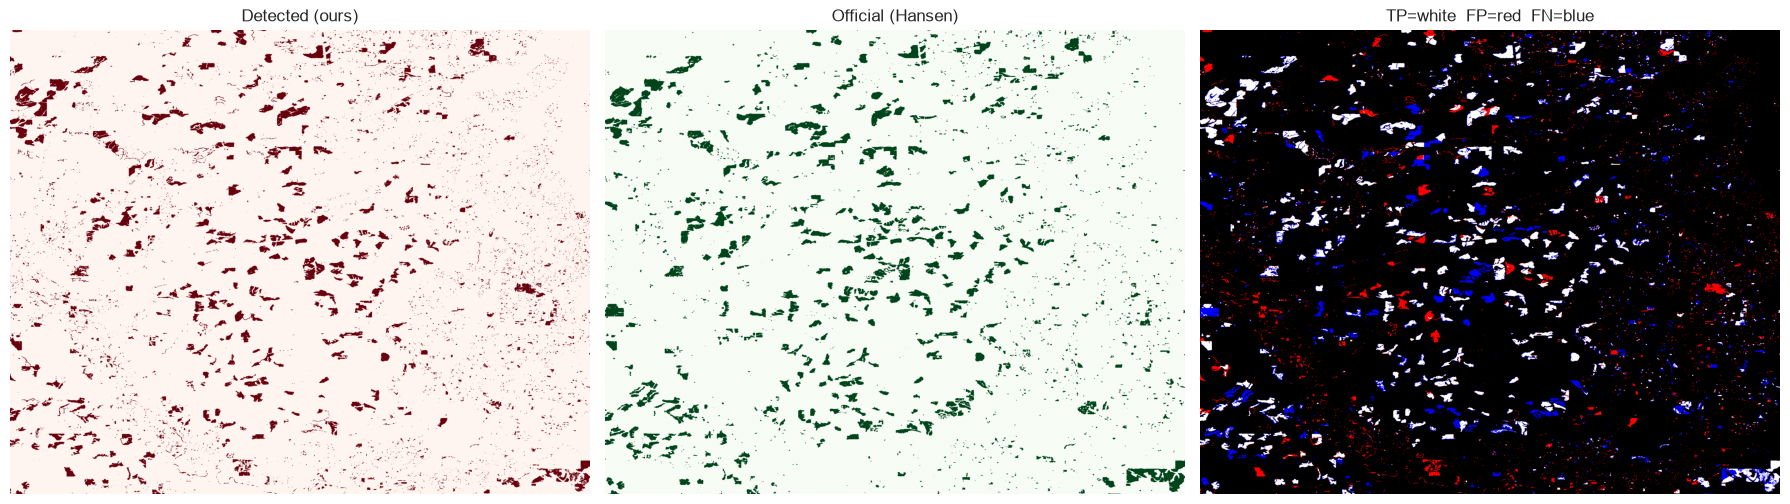

In [106]:
def hansen_loss_grid(hansen_path, year1, year2, frac_threshold=0.05):
    """Aggregate the Hansen lossyear raster to the tile grid.
    lossyear value = (year of loss − 2000); 0 means no loss."""
    lo, hi = year1 - 2000, year2 - 2000
    with rasterio.open(hansen_path) as src:
        arr = src.read(1).astype(np.int16)
    loss_px = (arr >= lo) & (arr <= hi)
    H, W = loss_px.shape
    rows, cols = H // TILE, W // TILE
    frac = loss_px[:rows*TILE, :cols*TILE].reshape(rows, TILE, cols, TILE).mean(axis=(1,3))
    return frac >= frac_threshold

hansen_path = os.path.join(SCENE_DIR, "hansen_lossyear.tif")
if "change_mask" in globals() and os.path.exists(hansen_path):
    official = hansen_loss_grid(hansen_path, YEAR_1, YEAR_2)
    # align shapes (rasters may differ by a row/col)
    R = min(change_mask.shape[0], official.shape[0]); C = min(change_mask.shape[1], official.shape[1])
    det, off = change_mask[:R,:C], official[:R,:C]

    TP = int((det & off).sum()); FP = int((det & ~off).sum())
    FN = int((~det & off).sum()); TN = int((~det & ~off).sum())
    precision = TP / (TP + FP + 1e-9)
    recall    = TP / (TP + FN + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    iou       = TP / (TP + FP + FN + 1e-9)

    print("Agreement with Global Forest Watch (Hansen):")
    print(f"  True positives : {TP}")
    print(f"  False positives: {FP}")
    print(f"  False negatives: {FN}")
    print(f"  Precision      : {precision:.3f}")
    print(f"  Recall         : {recall:.3f}")
    print(f"  F1             : {f1:.3f}")
    print(f"  IoU            : {iou:.3f}")

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    ax[0].imshow(det,  cmap="Reds");   ax[0].set_title("Detected (ours)");     ax[0].axis("off")
    ax[1].imshow(off,  cmap="Greens"); ax[1].set_title("Official (Hansen)");   ax[1].axis("off")
    agreement = np.zeros((*det.shape, 3))
    agreement[det & off]   = [1,1,1]      # TP white
    agreement[det & ~off]  = [1,0,0]      # FP red
    agreement[~det & off]  = [0,0,1]      # FN blue
    ax[2].imshow(agreement); ax[2].set_title("TP=white  FP=red  FN=blue"); ax[2].axis("off")
    plt.tight_layout(); plt.savefig(os.path.join(ASSETS_DIR, "validation.png"), dpi=150); plt.show()

    json.dump({"TP":TP,"FP":FP,"FN":FN,"TN":TN,"precision":precision,"recall":recall,
               "f1":f1,"iou":iou}, open(os.path.join(ASSETS_DIR,"validation.json"),"w"), indent=2)
else:
    print("Need change_mask (3.4) and data/study_region/hansen_lossyear.tif first.")

In [104]:
print("change_mask:", change_mask.shape)
print("official   :", official.shape)


change_mask: (1485, 1855)
official   : (1485, 1855)


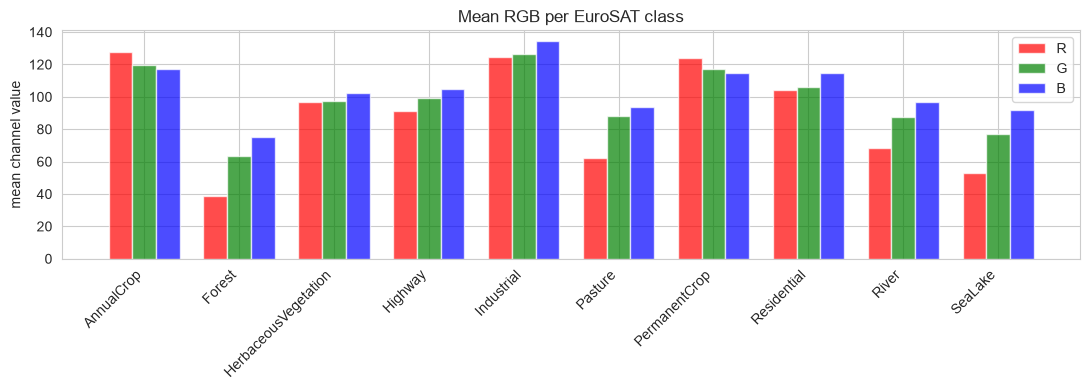

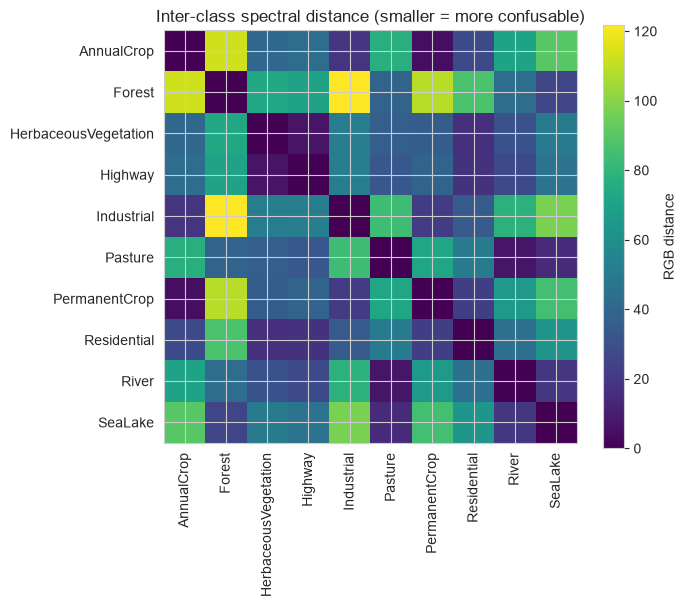

In [111]:
import numpy as np, os
from PIL import Image
import matplotlib.pyplot as plt

# mean R,G,B per class (sample 120 images/class for speed)
means = {}
for cls in LABELS:
    files = os.listdir(os.path.join(DATA_DIR, cls))[:120]
    px = np.stack([np.array(Image.open(os.path.join(DATA_DIR, cls, f)).resize((32,32)))[..., :3]
                   for f in files]).reshape(-1, 3)
    means[cls] = px.mean(0)

M = np.array([means[c] for c in LABELS])
fig, ax = plt.subplots(figsize=(11,4))
x = np.arange(len(LABELS))
for i,(col,name) in enumerate(zip(["red","green","blue"], ["R","G","B"])):
    ax.bar(x + i*0.25, M[:,i], width=0.25, color=col, alpha=0.7, label=name)
ax.set_xticks(x+0.25); ax.set_xticklabels(LABELS, rotation=45, ha="right")
ax.set_ylabel("mean channel value"); ax.set_title("Mean RGB per EuroSAT class")
ax.legend(); plt.tight_layout(); plt.savefig(os.path.join(ASSETS_DIR,"eda_class_rgb.png"), dpi=150); plt.show()

# pairwise spectral distance — which classes look alike?
from scipy.spatial.distance import cdist
D = cdist(M, M)
plt.figure(figsize=(7,6))
plt.imshow(D, cmap="viridis")
plt.xticks(range(len(LABELS)), LABELS, rotation=90); plt.yticks(range(len(LABELS)), LABELS)
plt.colorbar(label="RGB distance"); plt.title("Inter-class spectral distance (smaller = more confusable)")
plt.tight_layout(); plt.savefig(os.path.join(ASSETS_DIR,"eda_class_distance.png"), dpi=150); plt.show()

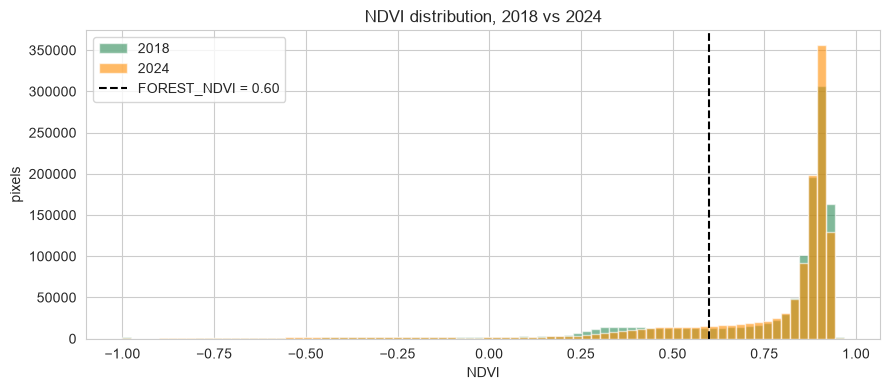

In [112]:
import rasterio
ndvi1 = rasterio.open(os.path.join(SCENE_DIR, f"ndvi_{YEAR_1}.tif")).read(1).astype(np.float32)
ndvi2 = rasterio.open(os.path.join(SCENE_DIR, f"ndvi_{YEAR_2}.tif")).read(1).astype(np.float32)

s1, s2 = ndvi1.ravel()[::20], ndvi2.ravel()[::20]   # subsample for the histogram
plt.figure(figsize=(9,4))
plt.hist(s1, bins=80, alpha=0.6, label=f"{YEAR_1}", color="seagreen")
plt.hist(s2, bins=80, alpha=0.6, label=f"{YEAR_2}", color="darkorange")
plt.axvline(0.60, ls="--", c="k", label="FOREST_NDVI = 0.60")
plt.xlabel("NDVI"); plt.ylabel("pixels"); plt.legend()
plt.title(f"NDVI distribution, {YEAR_1} vs {YEAR_2}")
plt.tight_layout(); plt.savefig(os.path.join(ASSETS_DIR,"eda_ndvi_hist.png"), dpi=150); plt.show()

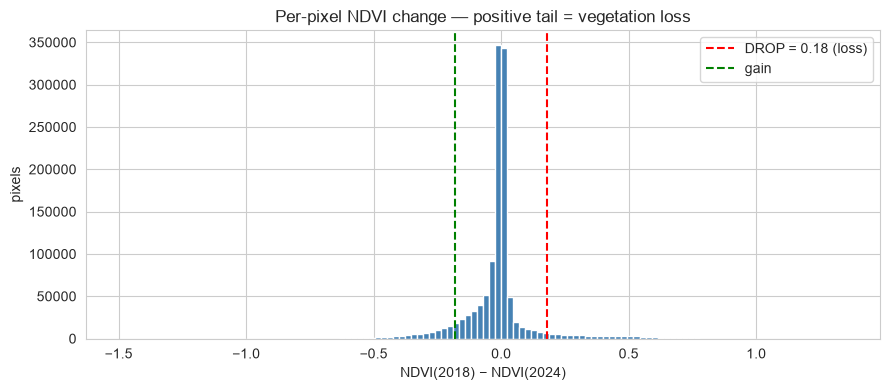

median change: nan | >0.18: 0.0548


In [113]:
diff = (ndvi1 - ndvi2).ravel()[::20]
plt.figure(figsize=(9,4))
plt.hist(diff, bins=120, color="steelblue")
plt.axvline(0.18, ls="--", c="r", label="DROP = 0.18 (loss)")
plt.axvline(-0.18, ls="--", c="g", label="gain")
plt.xlabel("NDVI(2018) − NDVI(2024)"); plt.ylabel("pixels"); plt.legend()
plt.title("Per-pixel NDVI change — positive tail = vegetation loss")
plt.tight_layout(); plt.savefig(os.path.join(ASSETS_DIR,"eda_ndvi_diff.png"), dpi=150); plt.show()
print("median change:", np.median(diff).round(4), "| >0.18:", (diff>0.18).mean().round(4))

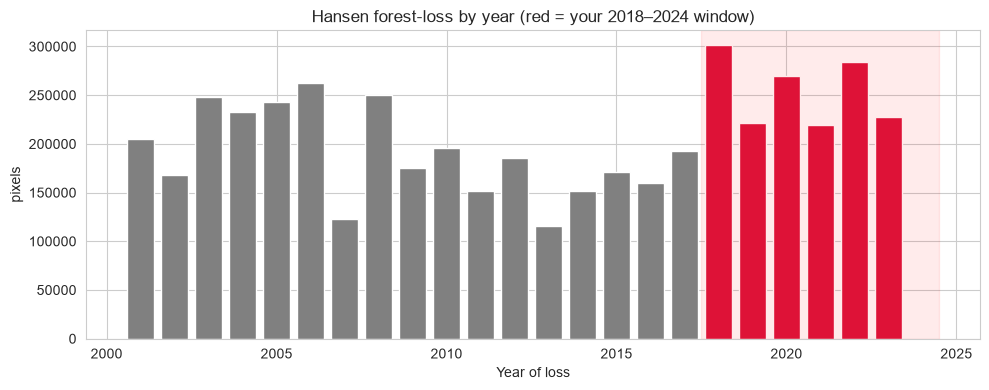

total loss pixels: 4,755,123 | in 2018–2024 window: 1,522,900 (32.0%)


In [116]:
hansen = rasterio.open(os.path.join(SCENE_DIR, "hansen_lossyear.tif")).read(1)
years = hansen[hansen > 0].astype(np.int16)          # cast so year math doesn't overflow
vals, counts = np.unique(years, return_counts=True)
vals = vals.astype(np.int16)                          # <-- ensures vals + 2000 is safe

plt.figure(figsize=(10,4))
colors = ["crimson" if (YEAR_1-2000) <= v <= (YEAR_2-2000) else "grey" for v in vals]
plt.bar(vals + 2000, counts, color=colors)
plt.axvspan(YEAR_1-0.5, YEAR_2+0.5, color="red", alpha=0.08)
plt.xlabel("Year of loss"); plt.ylabel("pixels")
plt.title("Hansen forest-loss by year (red = your 2018–2024 window)")
plt.tight_layout(); plt.savefig(os.path.join(ASSETS_DIR,"eda_hansen_years.png"), dpi=150); plt.show()

in_win = ((years >= YEAR_1-2000) & (years <= YEAR_2-2000)).sum()
print(f"total loss pixels: {years.size:,} | in 2018–2024 window: {in_win:,} ({in_win/years.size:.1%})")

<a id="5"></a>
## 5. Conclusion, limitations & next steps

**Summary.** This notebook trained an EuroSAT ResNet-50 land-cover classifier via two-stage
transfer learning, applied it to two-date Sentinel-2 imagery of a single region, detected
Forest→non-forest transitions, and quantified agreement with the Hansen / Global Forest Watch
loss layer.

**Interpreting the validation.** Precision tells you how many of the system's deforestation
alerts coincide with officially recorded loss; recall tells you how much official loss the
system recovered. Both should be read together with the confusion matrix from §2.5 — a model
that confuses *Forest* with *HerbaceousVegetation* will produce systematic change-detection
errors.

**Known limitations.**
- *Tile granularity.* 64×64 tiles (640 m) are coarse; sub-tile clearings are missed. Overlapping
  windows or a segmentation model (e.g. U-Net) would sharpen boundaries.
- *Domain shift.* EuroSAT is European; a study region elsewhere may need a few labelled local
  tiles for calibration.
- *Spectral limits.* Using only RGB discards near-infrared, which is highly informative for
  vegetation; adding NIR/NDVI bands is a natural improvement.
- *Temporal aliasing.* Median composites blur within-year seasonality; cloud contamination can
  still leak through.

**Next steps.** Multi-band (NIR/SWIR) input · semantic segmentation for pixel-level masks ·
multiple study regions · an ablation comparing ResNet-50 with VGG-19/ResNet-50V2 for the paper.

---
*This notebook is the full pipeline for the project; the `src/` modules mirror its logic as a
command-line workflow for headless/reproducible runs.*